In [123]:
import numpy as np
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fftshift
import matplotlib.pyplot as plt
import librosa
from scipy.signal import hilbert, butter, lfilter

In [124]:
def plot_spectogram(signal, srate):
    stft = librosa.stft(signal)
    spect = np.abs(stft)
    spectogram_db = librosa.amplitude_to_db(spect)
    plt.Figure(figsize=(10,4))
    img = librosa.display.specshow(spectogram_db,y_axis='mel', x_axis='time', sr=srate, cmap='inferno', fmin=4096)
    plt.colorbar(img, format="%+2.0f dB")
    plt.show()

In [125]:
def plot_filter(b,a):
    w, h = signal.freqs(b, a)
    plt.semilogx(w, 20 * np.log10(abs(h)))
    plt.title('Butterworth filter frequency response')
    plt.xlabel('Frequency [radians / second]')
    plt.ylabel('Amplitude [dB]')
    plt.margins(0, 0.1)
    plt.grid(which='both', axis='both')
    plt.axvline(100, color='green') # cutoff frequency
    plt.show()

In [126]:
# I got the code from here https://stackoverflow.com/questions/12093594/how-to-implement-band-pass-butterworth-filter-with-scipy-signal-butter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band') # from scipy.signal
    return b, a


def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    #plot_filter(b,a)
    y = lfilter(b, a, data)
    return y

In [127]:
# I got this code from here https://github.com/musikalkemist/AudioSignalProcessingForML/blob/master/8-%20Implementing%20the%20amplitude%20envelope/Implementing%20the%20amplitude%20envelope.ipynb
def fancy_amplitude_envelope(signal, frame_size, hop_length):
    # from 
    """Fancier Python code to calculate the amplitude envelope of a signal with a given frame size."""
    return np.array([max(signal[i:i+frame_size]) for i in range(0, len(signal), hop_length)])

In [128]:
song_file = "Training_set_YH_songs/ALL_Songs_CUT/20240726_forest_6_5m_0_9_test1_YH_1_D_1.wav"
samplerate, data = wavfile.read(song_file)
data = data.astype(float)

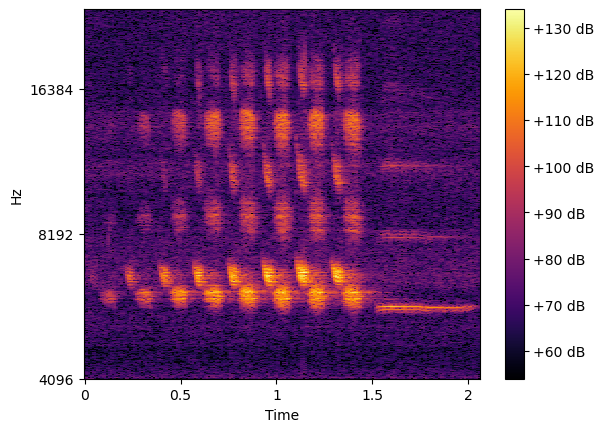

In [129]:
plot_spectogram(data, samplerate)

In [130]:
y = butter_bandpass_filter(data, 4000, 5000, samplerate, order=6)
z = butter_bandpass_filter(data, 6000, 8000, samplerate, order=6)

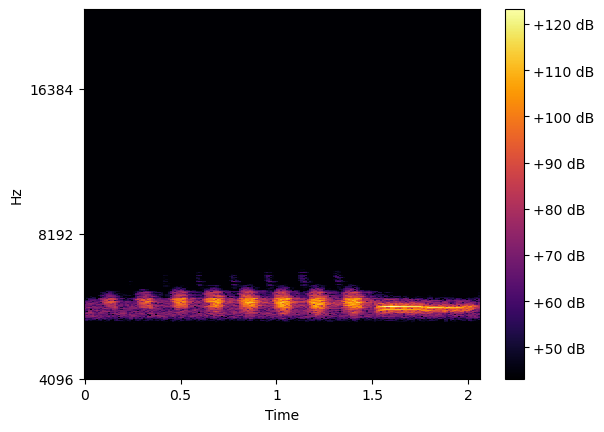

In [131]:
plot_spectogram(y, samplerate)

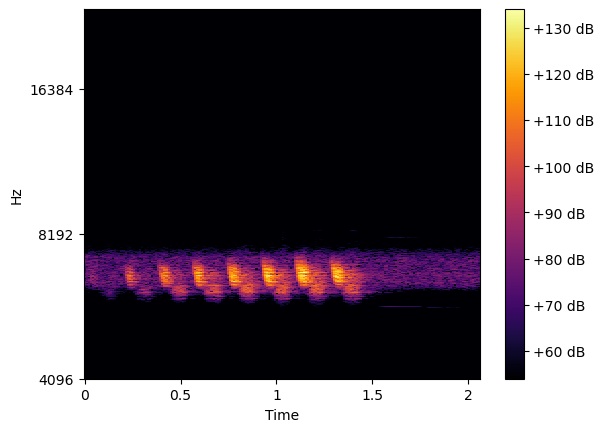

In [132]:
plot_spectogram(z, samplerate)

Text(0.5, 1.0, 'Amplitude Envelope')

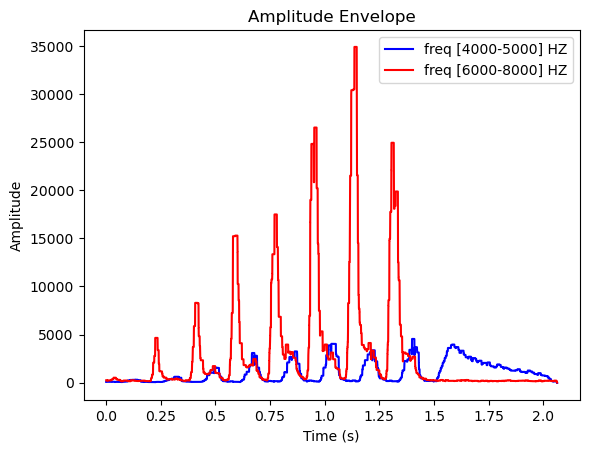

In [183]:
FRAME_SIZE = 512
HOP_LENGTH = 1

#plt.plot(y)
amplitude_envelope = fancy_amplitude_envelope(y,FRAME_SIZE, HOP_LENGTH)
amplitude_envelope_2 = fancy_amplitude_envelope(z,FRAME_SIZE, HOP_LENGTH)

plt.plot(amplitude_envelope, color="blue", label="freq [4000-5000] HZ")
plt.plot(amplitude_envelope_2, color="red", label="freq [6000-8000] HZ")

xticks = np.arange(0, 2.25, 0.25)
plt.xticks(xticks*samplerate,labels=xticks)
plt.legend()
plt.ylabel("Amplitude")
plt.xlabel("Time (s)")
plt.title("Amplitude Envelope")

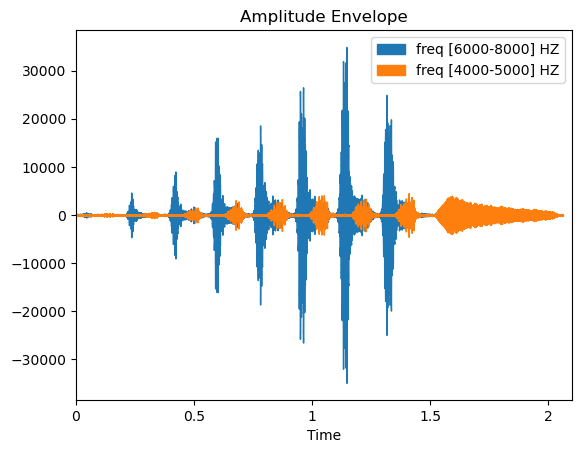

In [182]:
FRAME_SIZE = 512
HOP_LENGTH = 1

#plt.plot(y)
amplitude_envelope = fancy_amplitude_envelope(y,FRAME_SIZE, HOP_LENGTH)
amplitude_envelope_2 = fancy_amplitude_envelope(z,FRAME_SIZE, HOP_LENGTH)


fig, ax = plt.subplots(nrows=1, sharex=True)
ax.set(xlim=[0, 2.1], title='Amplitude Envelope')
librosa.display.waveshow(z, sr=samplerate, ax=ax, marker='.', label='freq [6000-8000] HZ')
librosa.display.waveshow(y, sr=samplerate, ax=ax, marker='.', label='freq [4000-5000] HZ')
ax.legend()